In [ ]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

pred_dir = Path("/home/akapociu/ift/interactiondynamics/results/wave")
#pred_dir = Path("/home/akapociu/ift/interactiondynamics/results/wave/testing")

rows = []

for npz_path in sorted(pred_dir.glob("*.npz")):
    fname = npz_path.name

    # keep ONLY IFT aggregator + IFT update runs
    if ("agg-ift" not in fname) or ("ift_update" not in fname):
        continue

    arr = np.load(npz_path)
    times = arr["times"]
    y_true = arr["y_true"]
    y_pred = arr["y_pred"]

    # flatten everything for global metrics
    true_flat = y_true.reshape(-1)
    pred_flat = y_pred.reshape(-1)

    mae = np.mean(np.abs(true_flat - pred_flat))
    rmse = np.sqrt(np.mean((true_flat - pred_flat) ** 2))

    # global Pearson / Spearman
    if np.std(true_flat) < 1e-12 or np.std(pred_flat) < 1e-12:
        global_pearson = np.nan
        global_spearman = np.nan
    else:
        global_pearson = pearsonr(true_flat, pred_flat)[0]
        global_spearman = spearmanr(true_flat, pred_flat)[0]

    # node-wise Pearson / Spearman
    T, N, D = y_true.shape
    node_pearsons = []
    node_spearmans = []

    for node_idx in range(N):
        for d in range(D):
            t_node = y_true[:, node_idx, d]
            p_node = y_pred[:, node_idx, d]

            if np.std(t_node) < 1e-12 or np.std(p_node) < 1e-12:
                continue

            node_pearsons.append(pearsonr(t_node, p_node)[0])
            node_spearmans.append(spearmanr(t_node, p_node)[0])

    mean_node_pearson = np.mean(node_pearsons) if node_pearsons else np.nan
    median_node_pearson = np.median(node_pearsons) if node_pearsons else np.nan
    mean_node_spearman = np.mean(node_spearmans) if node_spearmans else np.nan
    median_node_spearman = np.median(node_spearmans) if node_spearmans else np.nan

    # strip file extension
    run_name = npz_path.stem

    # remove seed from the config label so we can group across seeds
    # example: "...|seed=0" or "..._seed=0"
    model_config = re.sub(r'([|_])seed=\d+', '', run_name)

    # if your filenames have dataset prefix/suffix junk you want to remove,
    # you can tweak model_config here later

    seed_match = re.search(r'seed=(\d+)', run_name)
    seed = int(seed_match.group(1)) if seed_match else np.nan

    rows.append({
        "file": fname,
        "run_name": run_name,
        "model_config": model_config,
        "seed": seed,
        "mae": mae,
        "rmse": rmse,
        "global_pearson": global_pearson,
        "global_spearman": global_spearman,
        "mean_node_pearson": mean_node_pearson,
        "median_node_pearson": median_node_pearson,
        "mean_node_spearman": mean_node_spearman,
        "median_node_spearman": median_node_spearman,
    })

metrics_df = pd.DataFrame(rows)

print("Number of IFT + IFT update prediction files found:", len(metrics_df))
display(metrics_df.head())

# group across seeds to get one row per exact model config (without seed)
config_metrics_df = (
    metrics_df
    .groupby("model_config", as_index=False)
    .agg(
        avg_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        avg_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        avg_global_pearson=("global_pearson", "mean"),
        std_global_pearson=("global_pearson", "std"),
        avg_global_spearman=("global_spearman", "mean"),
        std_global_spearman=("global_spearman", "std"),
        n_seeds=("file", "count"),
    )
)

#display(config_metrics_df.sort_values("avg_global_pearson", ascending=False).head(10))
#display(config_metrics_df.sort_values("avg_global_spearman", ascending=False).head(10))

Number of IFT + IFT update prediction files found: 1550


,file,run_name,model_config,seed,mae,rmse,global_pearson,global_spearman,mean_node_pearson,median_node_pearson,mean_node_spearman,median_node_spearman
0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-1.0_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-1.0_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-1.0_seed-0,NaN,8.175044,10.126086,-0.029606,-0.033832,0.011985,-0.002403,0.023081,-0.012281
1,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-2.0_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-2.0_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-2.0_seed-0,NaN,8.175044,10.126086,-0.029606,-0.033832,0.011985,-0.002403,0.023081,-0.012281
2,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-5.0_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-5.0_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-5.0_seed-0,NaN,8.175044,10.126086,-0.029606,-0.033832,0.011985,-0.002403,0.023081,-0.012281
3,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-none_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-none_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-none_seed-0,NaN,8.175044,10.126086,-0.029606,-0.033832,0.011985,-0.002403,0.023081,-0.012281
4,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.5__cap-1.0_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.5__cap-1.0_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.5__cap-1.0_seed-0,NaN,8.176756,10.128010,-0.062632,-0.041837,0.010390,0.016674,0.030702,0.013158


/tmp/ipykernel_3291418/3665325398.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


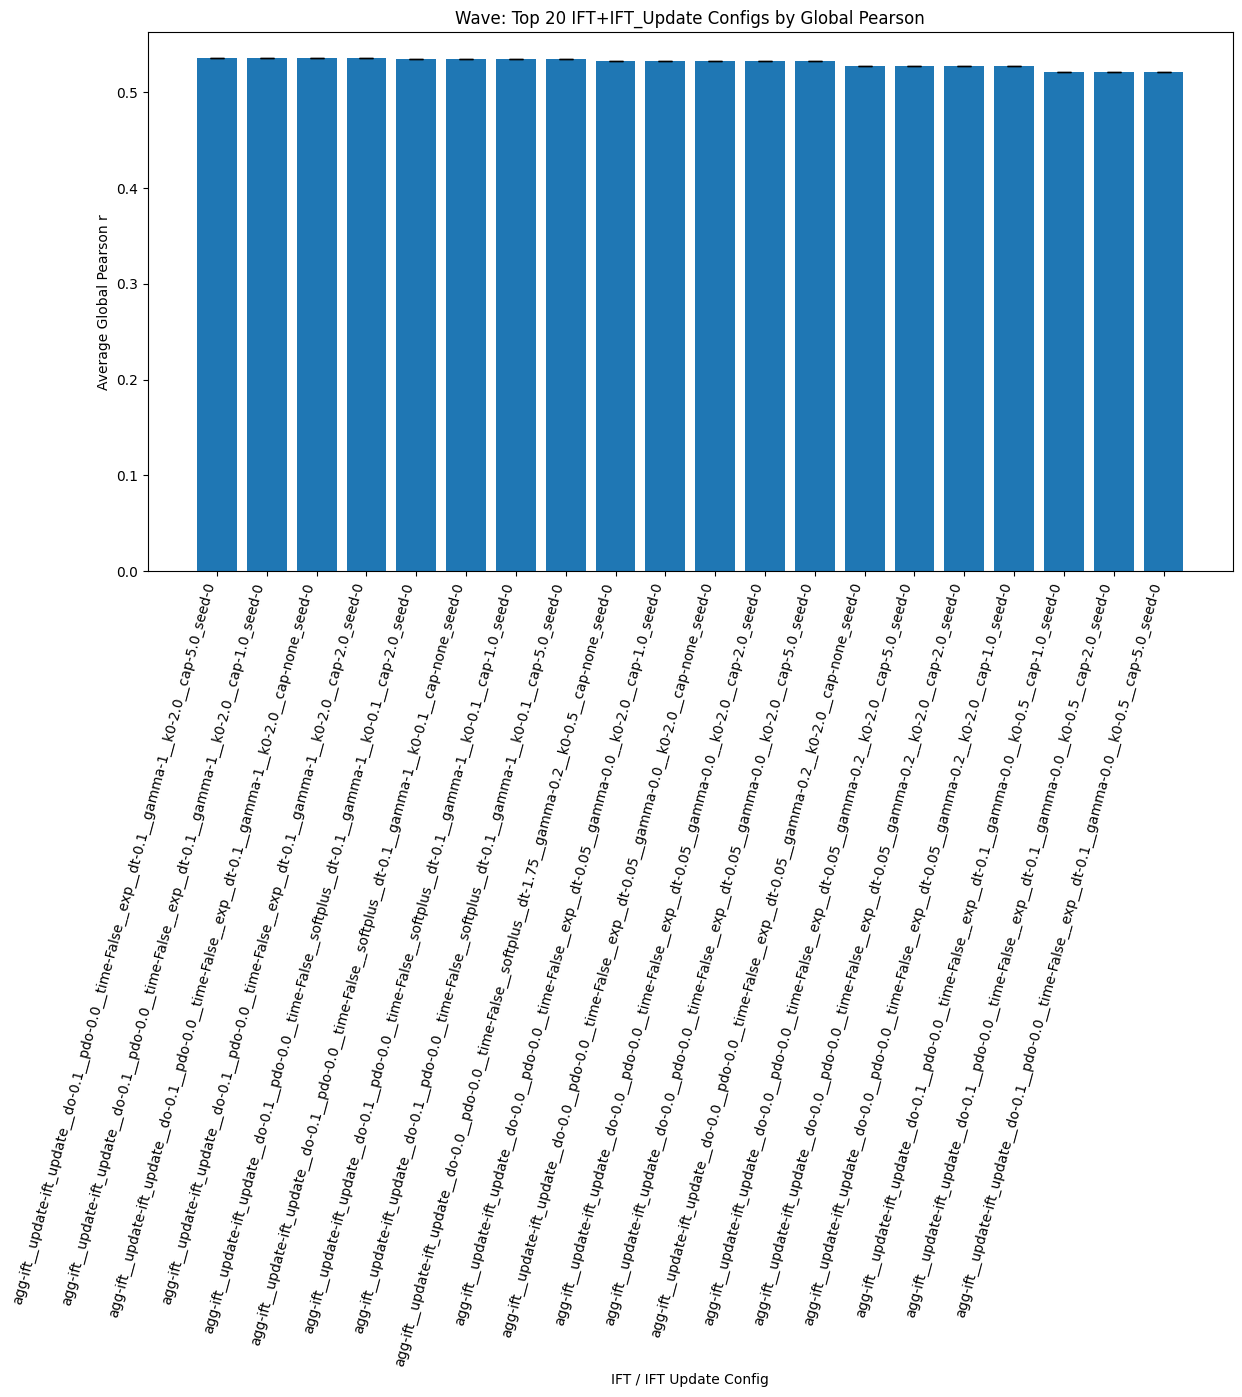

In [47]:
import matplotlib.pyplot as plt

top_k = 20

plot_df = (
    config_metrics_df
    .dropna(subset=["avg_global_pearson"])
    .sort_values("avg_global_pearson", ascending=False)
    .head(top_k)
    .copy()
)

plt.figure(figsize=(14, 7))
plt.bar(
    plot_df["model_config"],
    plot_df["avg_global_pearson"],
    yerr=plot_df["std_global_pearson"].fillna(0.0),
    capsize=5,
)

plt.ylabel("Average Global Pearson r")
plt.xlabel("IFT / IFT Update Config")
plt.title("Wave: Top 20 IFT+IFT_Update Configs by Global Pearson")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3291418/1180494904.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


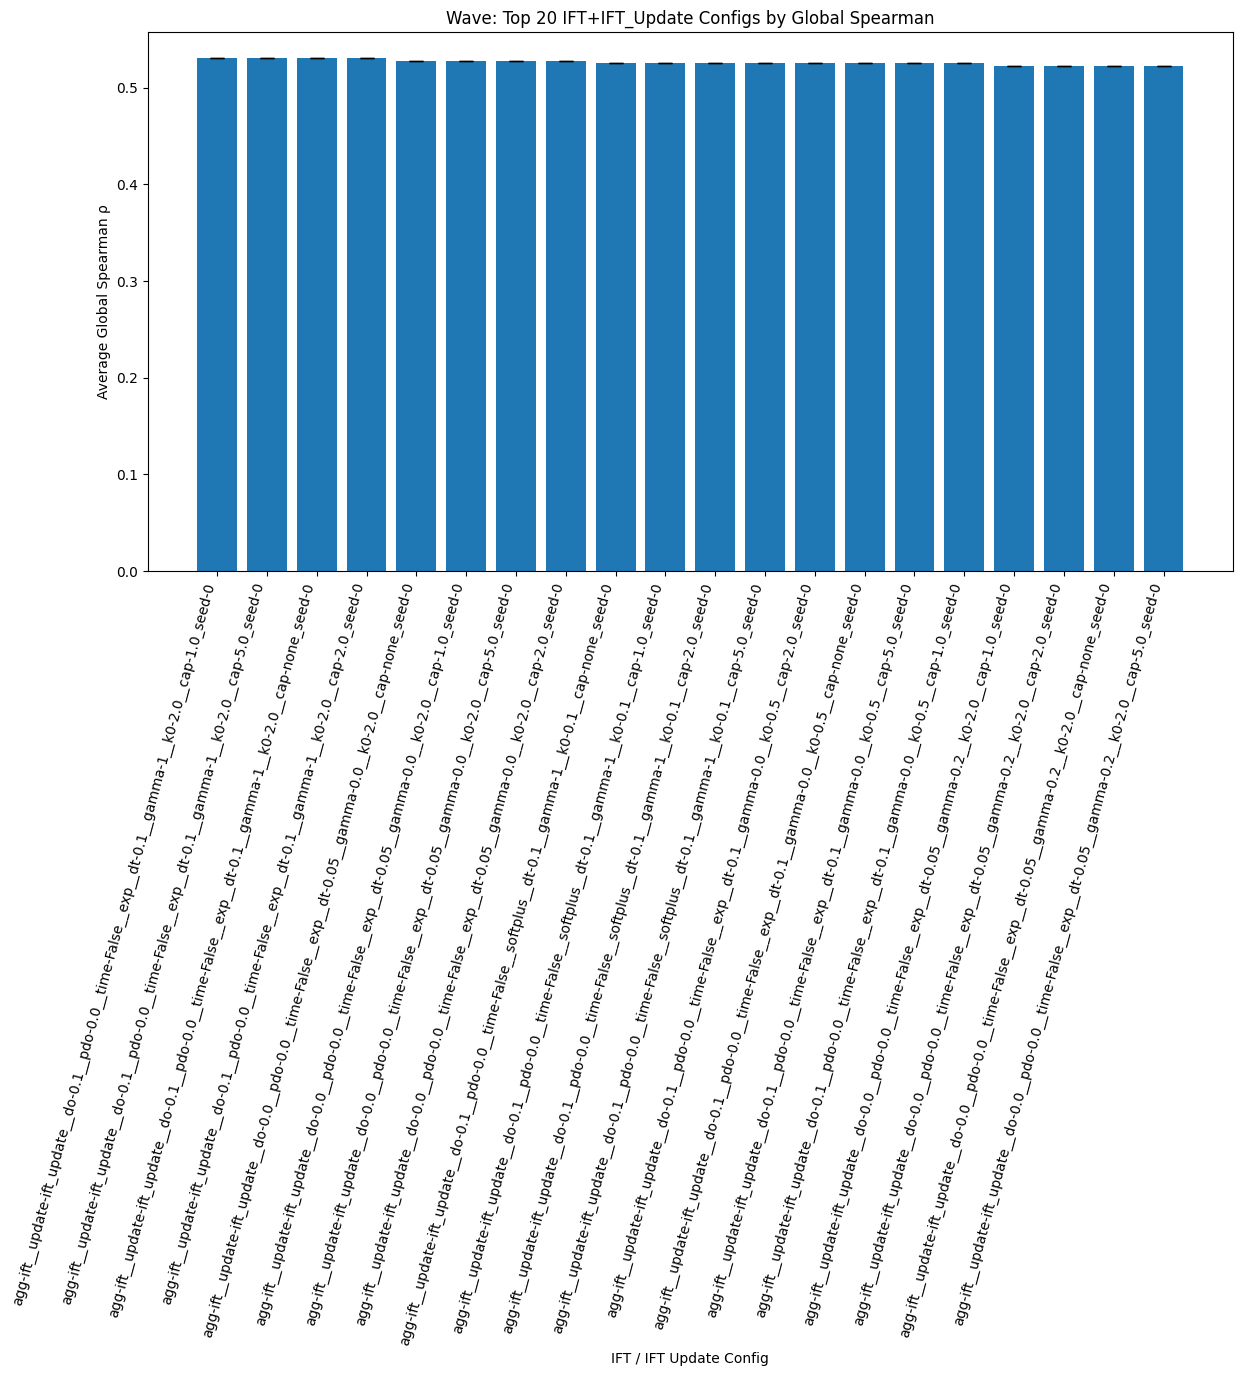

In [48]:
top_k = 20

plot_df = (
    config_metrics_df
    .dropna(subset=["avg_global_spearman"])
    .sort_values("avg_global_spearman", ascending=False)
    .head(top_k)
    .copy()
)

plt.figure(figsize=(14, 7))
plt.bar(
    plot_df["model_config"],
    plot_df["avg_global_spearman"],
    yerr=plot_df["std_global_spearman"].fillna(0.0),
    capsize=5,
)

plt.ylabel("Average Global Spearman ρ")
plt.xlabel("IFT / IFT Update Config")
plt.title("Wave: Top 20 IFT+IFT_Update Configs by Global Spearman")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [49]:
true_flat = y_true.reshape(-1)
pred_flat = y_pred.reshape(-1)

print("true std :", np.std(true_flat))
print("pred std :", np.std(pred_flat))
print("pred/true std ratio :", np.std(pred_flat) / (np.std(true_flat) + 1e-12))

true std : 10.125631
pred std : 1.1672348
pred/true std ratio : 0.11527526


In [50]:
a, b = np.polyfit(true_flat, pred_flat, 1)
print("slope a:", a)
print("intercept b:", b)

slope a: 0.04832505587007626
intercept b: 0.5284388278859733


In [51]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

pred_dir = Path("/home/akapociu/ift/interactiondynamics/results/wave/fes")

rows = []

for npz_path in sorted(pred_dir.glob("*.npz")):
    fname = npz_path.name

    # keep ONLY IFT aggregator + IFT update runs
    if ("agg-ift" not in fname) or ("ift_update" not in fname):
        continue

    arr = np.load(npz_path)
    y_true = arr["y_true"]
    y_pred = arr["y_pred"]

    true_flat = y_true.reshape(-1)
    pred_flat = y_pred.reshape(-1)

    # finite mask just in case
    mask = np.isfinite(true_flat) & np.isfinite(pred_flat)
    true_flat = true_flat[mask]
    pred_flat = pred_flat[mask]

    if len(true_flat) == 0:
        continue

    mae = np.mean(np.abs(true_flat - pred_flat))
    rmse = np.sqrt(np.mean((true_flat - pred_flat) ** 2))

    std_true = np.std(true_flat)
    std_pred = np.std(pred_flat)
    std_ratio = std_pred / (std_true + 1e-12)

    if std_true < 1e-12 or std_pred < 1e-12:
        global_pearson = np.nan
        global_spearman = np.nan
        slope = np.nan
        intercept = np.nan
    else:
        global_pearson = pearsonr(true_flat, pred_flat)[0]
        global_spearman = spearmanr(true_flat, pred_flat)[0]

        # fit pred = slope * true + intercept
        slope, intercept = np.polyfit(true_flat, pred_flat, 1)

    run_name = npz_path.stem
    model_config = re.sub(r'([|_])seed=\d+', '', run_name)

    seed_match = re.search(r'seed=(\d+)', run_name)
    seed = int(seed_match.group(1)) if seed_match else np.nan

    rows.append({
        "file": fname,
        "run_name": run_name,
        "model_config": model_config,
        "seed": seed,
        "mae": mae,
        "rmse": rmse,
        "global_pearson": global_pearson,
        "global_spearman": global_spearman,
        "std_true": std_true,
        "std_pred": std_pred,
        "std_ratio": std_ratio,
        "slope": slope,
        "intercept": intercept,
    })

diagnostic_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

diagnostic_df = diagnostic_df.drop([781, 777])
print("Top 10 runs by std_ratio")
display(
    diagnostic_df
    .sort_values("std_ratio", ascending=False)
    .head(10)[[
        "run_name", "std_ratio",
        "slope", "global_pearson", "global_spearman", "mae", "rmse"
    ]]
)

print("Top 10 runs by slope")
display(
    diagnostic_df
    .sort_values("slope", ascending=False)
    .head(10)[[
        "run_name", "std_ratio",
        "slope", "global_pearson", "global_spearman", "mae", "rmse"
    ]]
)

Top 10 runs by std_ratio


,run_name,std_ratio,slope,global_pearson,global_spearman,mae,rmse
381,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-2.0__cap-2.0_seed-0,1.289545,-0.189460,-0.146920,-0.085538,12.745110,17.660875
383,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-2.0__cap-none_seed-0,1.289545,-0.189460,-0.146920,-0.085538,12.745110,17.660875
380,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-2.0__cap-1.0_seed-0,1.289545,-0.189460,-0.146920,-0.085538,12.745110,17.660875
382,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-2.0__cap-5.0_seed-0,1.289545,-0.189460,-0.146920,-0.085538,12.745110,17.660875
1163,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-2.0__cap-2.0_seed-0,1.212366,-0.181062,-0.149346,-0.081585,12.507041,17.042831
1162,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-2.0__cap-1.0_seed-0,1.212366,-0.181062,-0.149346,-0.081585,12.507041,17.042831
1165,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-2.0__cap-none_seed-0,1.212366,-0.181062,-0.149346,-0.081585,12.507041,17.042831
1164,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-2.0__cap-5.0_seed-0,1.212366,-0.181062,-0.149346,-0.081585,12.507041,17.042831
366,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.2__gamma-0.5__k0-2.0__cap-5.0_seed-0,1.102290,-0.160472,-0.145581,-0.085308,11.996714,16.175373
367,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.2__gamma-0.5__k0-2.0__cap-none_seed-0,1.102290,-0.160472,-0.145581,-0.085308,11.996714,16.175373


Top 10 runs by slope


,run_name,std_ratio,slope,global_pearson,global_spearman,mae,rmse
1154,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-1.0_seed-0,0.357853,0.103924,0.290409,0.275651,7.965921,9.907593
1155,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-2.0_seed-0,0.357853,0.103924,0.290409,0.275651,7.965921,9.907593
1156,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-5.0_seed-0,0.357853,0.103924,0.290409,0.275651,7.965921,9.907593
1157,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-none_seed-0,0.357853,0.103924,0.290409,0.275651,7.965921,9.907593
972,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.05__gamma-1__k0-2.0__cap-5.0_seed-0,0.197094,0.097432,0.494343,0.483516,7.508803,9.303763
973,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.05__gamma-1__k0-2.0__cap-none_seed-0,0.197094,0.097432,0.494343,0.483516,7.508803,9.303763
970,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.05__gamma-1__k0-2.0__cap-1.0_seed-0,0.197094,0.097432,0.494343,0.483516,7.508803,9.303763
971,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.05__gamma-1__k0-2.0__cap-2.0_seed-0,0.197094,0.097432,0.494343,0.483516,7.508803,9.303763
269,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.5__k0-2.0__cap-2.0_seed-0,0.174171,0.088205,0.506430,0.509430,7.540544,9.372600
271,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.5__k0-2.0__cap-none_seed-0,0.174171,0.088205,0.506430,0.509430,7.540544,9.372600


In [52]:
import re
import numpy as np
import pandas as pd

df = diagnostic_df.copy()   # or metrics_df.copy()

def parse_run_name(run_name: str) -> dict:
    """
    Parse names like:
    agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-1.0_seed-0
    """
    out = {
        "aggregator": np.nan,
        "update": np.nan,
        "dropout": np.nan,
        "pdo": np.nan,
        "time": np.nan,
        "kappa_param": np.nan,
        "dt": np.nan,
        "gamma": np.nan,
        "k0": np.nan,
        "cap": np.nan,
        "seed": np.nan,
    }

    s = str(run_name)

    # split off seed first
    seed_match = re.search(r'_seed-(\d+)$', s)
    if seed_match:
        out["seed"] = int(seed_match.group(1))
        s = re.sub(r'_seed-\d+$', '', s)

    parts = s.split("__")

    for part in parts:
        if part.startswith("agg-"):
            out["aggregator"] = part[len("agg-"):]
        elif part.startswith("update-"):
            out["update"] = part[len("update-"):]
        elif part.startswith("do-"):
            out["dropout"] = float(part[len("do-"):])
        elif part.startswith("pdo-"):
            out["pdo"] = float(part[len("pdo-"):])
        elif part.startswith("time-"):
            val = part[len("time-"):]
            out["time"] = True if val == "True" else False if val == "False" else val
        elif part in ("exp", "softplus"):
            out["kappa_param"] = part
        elif part.startswith("dt-"):
            out["dt"] = float(part[len("dt-"):])
        elif part.startswith("gamma-"):
            out["gamma"] = float(part[len("gamma-"):])
        elif part.startswith("k0-"):
            out["k0"] = float(part[len("k0-"):])
        elif part.startswith("cap-"):
            val = part[len("cap-"):]
            if val == "none":
                out["cap"] = "none"
            else:
                try:
                    out["cap"] = float(val)
                except ValueError:
                    out["cap"] = val

    return out

parsed = df["run_name"].apply(parse_run_name).apply(pd.Series)
analysis_df = pd.concat([df.reset_index(drop=True), parsed.reset_index(drop=True)], axis=1)

display(analysis_df.head())

,file,run_name,model_config,seed,mae,rmse,global_pearson,global_spearman,std_true,std_pred,std_ratio,slope,intercept,aggregator,update,dropout,pdo,time,kappa_param,dt,gamma,k0,cap,seed
0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-1.0_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-1.0_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-1.0_seed-0,NaN,8.175044,10.126086,-0.029606,-0.033832,10.125631,0.013755,0.001358,-0.000040,-0.028121,ift,ift_update,0.0,0.0,False,exp,0.01,0.05,0.1,1.0,0
1,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-2.0_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-2.0_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-2.0_seed-0,NaN,8.175044,10.126086,-0.029606,-0.033832,10.125631,0.013755,0.001358,-0.000040,-0.028121,ift,ift_update,0.0,0.0,False,exp,0.01,0.05,0.1,2.0,0
2,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-5.0_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-5.0_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-5.0_seed-0,NaN,8.175044,10.126086,-0.029606,-0.033832,10.125631,0.013755,0.001358,-0.000040,-0.028121,ift,ift_update,0.0,0.0,False,exp,0.01,0.05,0.1,5.0,0
3,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-none_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-none_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.1__cap-none_seed-0,NaN,8.175044,10.126086,-0.029606,-0.033832,10.125631,0.013755,0.001358,-0.000040,-0.028121,ift,ift_update,0.0,0.0,False,exp,0.01,0.05,0.1,none,0
4,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.5__cap-1.0_seed-0.npz,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.5__cap-1.0_seed-0,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.01__gamma-0.05__k0-0.5__cap-1.0_seed-0,NaN,8.176756,10.128010,-0.062632,-0.041837,10.125631,0.034990,0.003456,-0.000216,0.050692,ift,ift_update,0.0,0.0,False,exp,0.01,0.05,0.5,1.0,0


In [53]:
metric = "slope"   # change to global_spearman, std_ratio, slope, etc.

param_cols = [
    "aggregator", "update", "dropout", "pdo", "time",
    "kappa_param", "dt", "gamma", "k0", "cap"
]

summary_tables = {}

for col in param_cols:
    tbl = (
        analysis_df
        .groupby(col, dropna=False)
        .agg(
            mean_metric=(metric, "mean"),
            std_metric=(metric, "std"),
            n=(metric, "count"),
        )
        .reset_index()
        .sort_values("mean_metric", ascending=False)
    )
    summary_tables[col] = tbl
    print(f"\n=== {col} ===")
    display(tbl)

# rough "how much does this parameter seem to matter?"
importance_rows = []
for col, tbl in summary_tables.items():
    spread = tbl["mean_metric"].max() - tbl["mean_metric"].min()
    importance_rows.append({
        "parameter": col,
        "mean_metric_spread": spread,
        "num_levels": len(tbl),
    })

importance_df = pd.DataFrame(importance_rows).sort_values("mean_metric_spread", ascending=False)
print("\n=== Rough parameter influence ranking ===")
display(importance_df)


=== aggregator ===


,aggregator,mean_metric,std_metric,n
0,ift,0.004119,0.027739,1548



=== update ===


,update,mean_metric,std_metric,n
0,ift_update,0.004119,0.027739,1548



=== dropout ===


...

,k0,mean_metric,std_metric,n
2,0.200,0.025017,NaN,1
0,0.001,0.011020,NaN,1
4,1.000,0.008135,0.013980,384
3,0.500,0.005833,0.014129,393
1,0.100,0.004520,0.010606,385
5,2.000,-0.002128,0.050355,384



=== cap ===


,cap,mean_metric,std_metric,n
3,none,0.004497,0.027640,396
0,1.0,0.003989,0.027807,384
1,2.0,0.003989,0.027807,384
2,5.0,0.003989,0.027807,384



=== Rough parameter influence ranking ===


,parameter,mean_metric_spread,num_levels
6,dt,0.033990,11
8,k0,0.027144,6
7,gamma,0.007883,6
2,dropout,0.002478,2
5,kappa_param,0.002099,2
9,cap,0.000508,4
1,update,0.000000,1
0,aggregator,0.000000,1
4,time,0.000000,1
3,pdo,0.000000,1


In [54]:
metric = "slope"
top_k = 20

top_df = (
    analysis_df
    .sort_values(metric, ascending=False)
    .head(top_k)
    .copy()
)

print("Top runs:")
display(top_df[[
    "run_name", metric, "aggregator", "update", "kappa_param",
    "dt", "gamma", "k0", "cap", "dropout", "pdo"
]])

# Frequency of each single parameter value in top-k
for col in ["aggregator", "update", "kappa_param", "dt", "gamma", "k0", "cap", "dropout", "pdo"]:
    print(f"\n=== Top {top_k} frequency: {col} ===")
    display(top_df[col].value_counts(dropna=False).reset_index().rename(
        columns={"index": col, col: "count"}
    ))

# Pairwise combinations that show up together
pair_cols = [
    ("dt", "gamma"),
    ("dt", "k0"),
    ("gamma", "k0"),
    ("kappa_param", "dt"),
    ("kappa_param", "gamma"),
    ("cap", "dt"),
    ("cap", "gamma"),
]

for c1, c2 in pair_cols:
    print(f"\n=== Top {top_k} combo frequency: ({c1}, {c2}) ===")
    display(
        top_df
        .groupby([c1, c2])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

Top runs:


,run_name,slope,aggregator,update,kappa_param,dt,gamma,k0,cap,dropout,pdo
1152,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-1.0_seed-0,0.103924,ift,ift_update,exp,0.20,1.0,0.5,1.0,0.1,0.0
1153,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-2.0_seed-0,0.103924,ift,ift_update,exp,0.20,1.0,0.5,2.0,0.1,0.0
1154,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-5.0_seed-0,0.103924,ift,ift_update,exp,0.20,1.0,0.5,5.0,0.1,0.0
1155,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.2__gamma-1__k0-0.5__cap-none_seed-0,0.103924,ift,ift_update,exp,0.20,1.0,0.5,none,0.1,0.0
970,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.05__gamma-1__k0-2.0__cap-5.0_seed-0,0.097432,ift,ift_update,exp,0.05,1.0,2.0,5.0,0.1,0.0
971,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.05__gamma-1__k0-2.0__cap-none_seed-0,0.097432,ift,ift_update,exp,0.05,1.0,2.0,none,0.1,0.0
968,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.05__gamma-1__k0-2.0__cap-1.0_seed-0,0.097432,ift,ift_update,exp,0.05,1.0,2.0,1.0,0.1,0.0
969,agg-ift__update-ift_update__do-0.1__pdo-0.0__time-False__exp__dt-0.05__gamma-1__k0-2.0__cap-2.0_seed-0,0.097432,ift,ift_update,exp,0.05,1.0,2.0,2.0,0.1,0.0
269,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.5__k0-2.0__cap-2.0_seed-0,0.088205,ift,ift_update,exp,0.10,0.5,2.0,2.0,0.0,0.0
271,agg-ift__update-ift_update__do-0.0__pdo-0.0__time-False__exp__dt-0.1__gamma-0.5__k0-2.0__cap-none_seed-0,0.088205,ift,ift_update,exp,0.10,0.5,2.0,none,0.0,0.0



=== Top 20 frequency: aggregator ===


,count,count
0,ift,20



=== Top 20 frequency: update ===


...

,kappa_param,gamma,count
2,exp,1.0,12
0,exp,0.1,4
1,exp,0.5,4



=== Top 20 combo frequency: (cap, dt) ===


,cap,dt,count
1,1.0,0.10,2
2,1.0,0.20,2
5,2.0,0.20,2
4,2.0,0.10,2
11,none,0.20,2
10,none,0.10,2
7,5.0,0.10,2
8,5.0,0.20,2
3,2.0,0.05,1
0,1.0,0.05,1



=== Top 20 combo frequency: (cap, gamma) ===


,cap,gamma,count
2,1.0,1.0,3
11,none,1.0,3
8,5.0,1.0,3
5,2.0,1.0,3
3,2.0,0.1,1
1,1.0,0.5,1
0,1.0,0.1,1
4,2.0,0.5,1
7,5.0,0.5,1
6,5.0,0.1,1


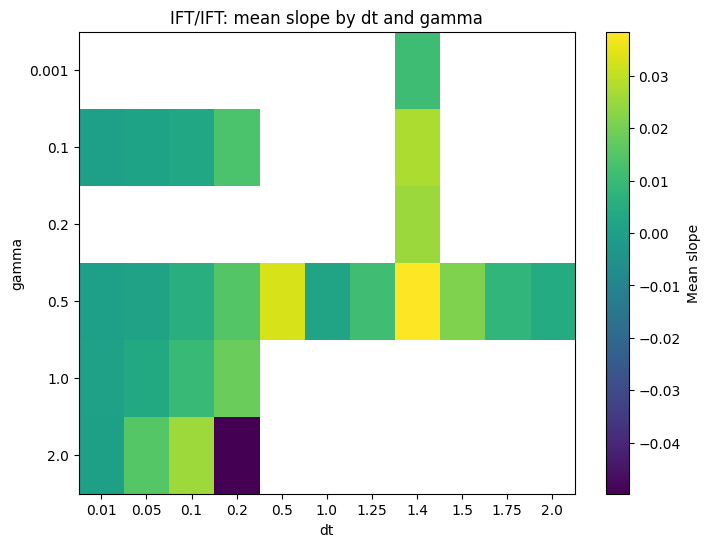

In [56]:
import matplotlib.pyplot as plt
ift_only_df = analysis_df[
    (analysis_df["aggregator"] == "ift") &
    (analysis_df["update"] == "ift_update")
].copy()

metric = "slope"

heat_df = (
    ift_only_df
    .groupby(["dt", "k0"])
    .agg(mean_metric=(metric, "mean"))
    .reset_index()
)

pivot = heat_df.pivot(index="k0", columns="dt", values="mean_metric")

plt.figure(figsize=(8, 6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label=f"Mean {metric}")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("dt")
plt.ylabel("gamma")
plt.title(f"IFT/IFT: mean {metric} by dt and gamma")
plt.show()